# Linking structure to function — closing figures

Two publication figures for the TFM (A. de Haro García, adv. M. Á. Serrano, UB):

* **Figure 1 — Memory capacity across the lifespan and its structural predictors.**
  ESN/MC paradigm (built from one real connectome) · MC, disparity, clustering and
  communicability trajectories · the MC–disparity developmental linearization ·
  a signed-*r* horse-race (development vs aging) and the structural-explanation bars.
* **Figure 2 — The communicability decomposition, the regime change, and the multivariate picture.**
  Taylor validation of the self-communicability expansion · the R² decomposition of MC
  (Table III) for development vs aging · a PCA of the coupled structural family.

Memory capacity is computed by five small C++/Eigen programs (`cpp/`, parallelised with
OpenMP). All structural quantities are computed here in Python from the connectome
matrices. Everything is cached to `procdata/`; set `FORCE_RECOMPUTE`/`FORCE_RECOMPILE`
to redo work. The notebook is autonomous: run top to bottom.


## 0 · Parameters

In [2]:
# ---- paths -----------------------------------------------------------------
from pathlib import Path
import os

DATA_PKL   = Path("../procdata/data_with_metrics.pkl")   # one row per connectome
WORK_DIR   = Path("procdata"); WORK_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR    = Path("figures");  FIG_DIR.mkdir(exist_ok=True, parents=True)
CPP_DATA   = Path("data");  CPP_DATA.mkdir(exist_ok=True, parents=True)

# ---- recompute switches ----------------------------------------------------
FORCE_RECOMPILE  = False    # rebuild the C++ binaries
FORCE_RECOMPUTE  = False    # rerun every C++ experiment (ignore caches)
SEED             = 42

# ---- toolchain knobs (one-time, Windows/MSYS2) -----------------------------
# Override if autodetection fails:
#   os.environ["GPP"]            = r"C:\msys64\ucrt64\bin\g++.exe"
#   os.environ["EIGEN_INCLUDE"]  = r"C:\path\to\eigen-master"
N_THREADS        = 0        # 0 = let OpenMP use all cores

# ---- ESN hyperparameters (kept reasonable; not tuned, per the manuscript) --
RES = dict(reservoir_size=90, spectral_radius=0.99, ridge=1e-6,
           train_ratio=0.7, washout=100)

# main MC experiment (all subjects -> the workhorse)
MAIN   = dict(steps=10000, tau=20, win_reps=1)
# surrogates / bio / ipc run on a balanced subject subset
SUBSET_N      = 100
SURR   = dict(steps=20000, tau=20, n_real=5)
BIO    = dict(steps=6000, tau=20, win_reps=1, thal_nodes="76,77", n_rand_pairs=50)
IPC    = dict(steps=6000, ipc_tau=6, ipc_cross=True, tau=20)
TRACE  = dict(steps=6000, tau=20, trace_window=200, trace_nodes=6, trace_taus="1,8")

# ---- analysis constants ----------------------------------------------------
AGE_SPLIT = 33                       # development (<33) vs aging (>=33); Mousley turn ~32
RHO       = 0.999                     # spectral-radius normalisation for communicability
N_AGE_BINS = 100                      # geometric age bins for trajectories
PLOT_SUBSET = 1500                   # max points drawn in scatter layers (age-balanced)

DS_NAMES = {1:"dHCP",2:"BCP",3:"CALM",4:"RED",5:"ACE",
            6:"HCPd",7:"HCPya",8:"camCAN",9:"HCPa"}
CAMCAN_DS = 8                        # for the Mijalkov thresholding contrast

FIG_PARTS  = FIG_DIR / "fig1_parts"; FIG_PARTS.mkdir(exist_ok=True, parents=True)
AAL_NII    = Path("../preprocdata/aal-SPM12/aal/atlas/AAL.nii")   # nilearn node glyph


def sig_stars(p):
    import numpy as np
    if not np.isfinite(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


## 1 · Imports and plotting style
Matches `firstpart.ipynb`. `networkx`/`umap` are optional — panels that need them degrade gracefully.

In [3]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import seaborn as sns
from scipy.linalg import expm, eigvals
from scipy.stats import pearsonr, f as f_dist
import warnings, subprocess, shutil, platform, pickle
warnings.filterwarnings("ignore")

try:
    import networkx as nx; HAS_NX = True
except Exception:
    HAS_NX = False
try:
    import umap; HAS_UMAP = True
except Exception:
    HAS_UMAP = False

sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "font.size":7, "axes.titlesize":7, "axes.labelsize":7,
    "xtick.labelsize":6, "ytick.labelsize":6, "legend.fontsize":6,
    "lines.linewidth":0.9, "lines.markersize":2.5,
    "figure.dpi":150, "savefig.dpi":300,
    "pdf.fonttype":42, "ps.fonttype":42, "svg.fonttype":"none",
    "axes.spines.top":False, "axes.spines.right":False,
})
FIGSIZE = (11, 7.5)

# colour-blind-safe palette used throughout
COL = dict(mc="#2A9D8F", disp="#C0392B", clust="#F39C12", comm="#2980B9",
           dev="#E1A100", aging="#6A3D9A", null="#9AA0A6", accent="#C0392B")
COHORT_COL = {"development": COL["dev"], "aging": COL["aging"]}
DS_PALETTE = dict(zip(range(1,10), sns.color_palette("tab10", 9)))

def save_fig(fig, name, d=None):
    d = d or FIG_DIR
    for ext in ("pdf","png"):
        fig.savefig(d / f"{name}.{ext}", dpi=300, bbox_inches="tight",
                    transparent=(d is not FIG_DIR))
    print("saved", d / f"{name}.[pdf|png]")
print("networkx:", HAS_NX, "| umap:", HAS_UMAP, "| platform:", platform.system())


networkx: True | umap: True | platform: Windows


## 2 · Structural helpers

The DataFrame already carries per-subject disparity (`Ratio` = Υ/Υ_null, `kY_obs`),
weighted clustering (`C_w`) and the off-diagonal communicability (`comm_mean`). Here we
add the quantities the **decomposition** needs and that are not pre-computed:

* the **diagonal self-communicability** $C_{ii}=(e^{W})_{ii}$ and its order-2 / order-3
  Taylor terms $\tfrac12(W^2)_{ii}$ (∝ disparity) and $(W^3)_{ii}/6$ (∝ clustering),
* per-node off-diagonal communicability $G_i$,
* Zhang–Horvath weighted clustering (its numerator *is* $(W^3)_{ii}$, so it is the
  clustering coefficient that matches the order-3 term exactly — Onnela's cube-root
  version is provided too for the text),

plus statistics utilities (OLS R², partial correlation, geometric-bin trajectories with
bootstrap CIs, proportional thresholding, age-balanced sampling).

In [4]:
# ---------- node-level weight statistics ----------
def node_metrics(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    s = A.sum(1); k = (A > 0).sum(1).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        P = np.where(s[:,None] > 0, A / s[:,None], 0.0)
    Y = (P**2).sum(1)
    return dict(strength=s, degree=k, disparity_Y=Y, kY=k*Y)

def spectral_normalize(A, rho=RHO):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    ev = np.abs(eigvals(A)); sr = ev.max() if ev.size else 0.0
    return A * (rho / sr) if sr > 0 else A

# ---------- communicability (diagonal = self/subgraph; off-diagonal = global) ----------
def communicability_parts(A, rho=RHO):
    W = spectral_normalize(A, rho); N = W.shape[0]
    C = expm(W); dC = np.diag(C).copy()
    off_mean = (C.sum() - dC.sum()) / (N*(N-1))
    off_node = (C.sum(1) - dC) / (N-1)
    return dict(W=W, self_comm=dC, G_off_mean=off_mean, G_off_node=off_node)

def taylor_terms(W):
    W2 = W @ W; W3 = W2 @ W
    t2 = 0.5*np.diag(W2)          # order-2  (∝ disparity:  (W^2)_ii = s^2 Y)
    t3 = np.diag(W3)/6.0          # order-3  (∝ clustering)
    return dict(t2=t2, t3=t3, approx2=1.0+t2)

# ---------- weighted clustering ----------
def clustering_zhang_horvath(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    m = A.max(); W = A/m if m > 0 else A
    num = np.diag(W @ W @ W)
    den = W.sum(1)**2 - (W**2).sum(1)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den > 0, num/den, 0.0)

def clustering_onnela(A):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0)
    m = A.max(); W = A/m if m > 0 else A
    Wc = np.cbrt(W); t = np.diag(Wc @ Wc @ Wc)
    k = (A > 0).sum(1).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(k > 1, t/(k*(k-1)), 0.0)

# ---------- statistics ----------
def fit_linear(X, y):
    X = np.asarray(X, float); y = np.asarray(y, float)
    if X.ndim == 1: X = X[:,None]
    M = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X, y = X[M], y[M]
    A = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    yhat = A @ beta
    ss_res = float(((y-yhat)**2).sum()); ss_tot = float(((y-y.mean())**2).sum())
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
    n, p = len(y), X.shape[1]
    if ss_res > 0 and n-p-1 > 0 and 0 < r2 < 1:
        F = (r2/p)/((1-r2)/(n-p-1)); pval = float(f_dist.sf(F, p, n-p-1))
    else:
        pval = np.nan
    return r2, pval

def pearson_p(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    M = np.isfinite(x) & np.isfinite(y)
    if M.sum() < 3: return np.nan, np.nan
    r, p = pearsonr(x[M], y[M]); return float(r), float(p)

def partial_r(x, y, covars):
    x = np.asarray(x, float); y = np.asarray(y, float)
    Z = np.asarray(covars, float)
    if Z.ndim == 1: Z = Z[:,None]
    M = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(Z), axis=1)
    x, y, Z = x[M], y[M], Z[M]
    if len(x) < 5: return np.nan, np.nan
    A = np.column_stack([np.ones(len(x)), Z])
    rx = x - A @ np.linalg.lstsq(A, x, rcond=None)[0]
    ry = y - A @ np.linalg.lstsq(A, y, rcond=None)[0]
    return pearson_p(rx, ry)

def fdr_bh(pvals):
    p = np.asarray(pvals, float); n = p.size
    if n == 0: return p
    order = np.argsort(p); ranked = np.empty(n); ranked[order] = np.arange(1, n+1)
    q = p * n / ranked
    qs = q[order]; qs = np.minimum.accumulate(qs[::-1])[::-1]
    out = np.empty(n); out[order] = qs
    return np.clip(out, 0, 1)

def binned_xy(x, y, n_bins=12, n_boot=400, seed=SEED, geom=False):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    if x.size < 6: return tuple(np.array([]) for _ in range(4))
    edges = (np.geomspace(max(x.min(),1e-6), x.max(), n_bins+1) if geom
             else np.linspace(x.min(), x.max(), n_bins+1))
    idx = np.clip(np.digitize(x, edges)-1, 0, n_bins-1)
    rng = np.random.default_rng(seed); cen, mean, lo, hi = [], [], [], []
    for b in range(n_bins):
        v = y[idx == b]
        if v.size < 3: continue
        cen.append(0.5*(edges[b]+edges[b+1])); mean.append(v.mean())
        bs = np.array([rng.choice(v, v.size, replace=True).mean() for _ in range(n_boot)])
        lo.append(np.percentile(bs, 2.5)); hi.append(np.percentile(bs, 97.5))
    return tuple(np.array(z) for z in (cen, mean, lo, hi))

# ---------- trajectories ----------
def geom_age_bins(age, n_bins=N_AGE_BINS, floor=0.25):
    a = np.clip(np.asarray(age, float), floor, None)
    edges = np.geomspace(a.min(), a.max(), n_bins+1)
    idx = np.clip(np.digitize(a, edges)-1, 0, n_bins-1)
    return edges, idx

def binned_trajectory(age, val, n_bins=N_AGE_BINS, n_boot=400, seed=SEED):
    age = np.asarray(age, float); val = np.asarray(val, float)
    M = np.isfinite(age) & np.isfinite(val); age, val = age[M], val[M]
    edges, idx = geom_age_bins(age, n_bins)
    rng = np.random.default_rng(seed)
    cen, mean, lo, hi = [], [], [], []
    for b in range(n_bins):
        v = val[idx == b]
        if v.size < 3: continue
        cen.append(float(np.sqrt(edges[b]*edges[b+1]))); mean.append(float(v.mean()))
        bs = np.array([rng.choice(v, v.size, replace=True).mean() for _ in range(n_boot)])
        lo.append(float(np.percentile(bs, 2.5))); hi.append(float(np.percentile(bs, 97.5)))
    return tuple(np.array(z) for z in (cen, mean, lo, hi))

# ---------- misc ----------
def proportional_threshold(A, density):
    A = np.asarray(A, float).copy(); np.fill_diagonal(A, 0.0); N = A.shape[0]
    iu = np.triu_indices(N, 1); w = A[iu]
    keep = int(round(density * w.size))
    if keep < 1 or (w > 0).sum() == 0: return np.zeros_like(A)
    thr = np.sort(w)[::-1][min(keep, w.size)-1]
    M = np.where(A >= thr, A, 0.0); np.fill_diagonal(M, 0.0); return M

def inverse_freq_sample(df, n, seed=SEED, age_col="age"):
    # age-balanced subsample: P(row) proportional to 1 / (#rows at that rounded age).
    # Done with numpy.choice (pandas' own weighted no-replacement sampler is overly strict).
    n = min(n, len(df))
    if n >= len(df):
        return df.copy()
    rng = np.random.default_rng(seed)
    vc = df[age_col].round().value_counts()
    w = (1.0 / df[age_col].round().map(vc)).fillna(0.0).to_numpy()
    if w.sum() <= 0:
        idx = rng.choice(len(df), size=n, replace=False)
    else:
        idx = rng.choice(len(df), size=n, replace=False, p=w / w.sum())
    return df.iloc[idx]


## 3 · Load data, derive features, choose the analysis sample

We load `data_with_metrics.pkl`, build a stable `sid = arange(len(df))` (used as the
C++ merge key, since there is no subject id), and compute the per-subject decomposition
features (mean self-communicability, mean order-2/order-3 Taylor terms, mean
Zhang–Horvath clustering, mean off-diagonal $G_i$) directly from the `connectome`
matrices. The columns already present (`Ratio`, `kY_obs`, `C_w`, `comm_mean`,
`strength`, `degree`, `density`) are reused as-is.

In [5]:
assert DATA_PKL.exists(), f"missing {DATA_PKL} — put data_with_metrics.pkl under procdata/"
df = pd.read_pickle(DATA_PKL).reset_index(drop=True)
df["sid"] = np.arange(len(df))
print(f"{len(df)} connectomes | columns: {list(df.columns)}")
print("datasets:", sorted(df['dataset'].unique()), "| age range:",
      round(df['age'].min(),2), "-", round(df['age'].max(),2))

def _mat(x):
    A = np.asarray(x, float)
    if A.ndim == 1:                      # flattened -> square
        n = int(round(np.sqrt(A.size))); A = A.reshape(n, n)
    np.fill_diagonal(A, 0.0); return A

N_NODES = _mat(df.iloc[0]["connectome"]).shape[0]
print("N nodes per connectome:", N_NODES)
RES["reservoir_size"] = N_NODES


3901 connectomes | columns: ['age', 'dataset', 'sex', 'connectome', 'decade', 'density', 'strength', 'degree', 'Y_obs', 'kY_obs', 'Y_null', 'Ratio', 'C_unw', 'C_w', 'comm_mean', 'sid']
datasets: [1, 2, 3, 4, 5, 6, 7, 8, 9] | age range: 0 - 90
N nodes per connectome: 90


In [ ]:
# Check connectomes for (1) self-loops and (2) non-symmetry
n_total = len(df)
self_loop_count = 0
nonsym_count = 0

for A_raw in df["connectome"]:
    A = np.asarray(A_raw, dtype=float)
    if A.ndim == 1:  # flattened connectome
        n = int(round(np.sqrt(A.size)))
        A = A.reshape(n, n)

    if np.any(np.diag(A) != 0):
        self_loop_count += 1

    if not np.allclose(A, A.T, atol=1e-10, rtol=0):
        nonsym_count += 1

print(f"Total connectomes: {n_total}")
print(f"Self-loops: {self_loop_count}/{n_total} ({self_loop_count/n_total:.2%})")
print(f"Non-symmetric: {nonsym_count}/{n_total} ({nonsym_count/n_total:.2%})")


In [6]:
# ---- per-subject decomposition features (cached: depends only on connectomes) ----
FEAT_PKL = WORK_DIR / "struct_features.pkl"
if FEAT_PKL.exists():
    feats = pd.read_pickle(FEAT_PKL)
    print("loaded cached structural features:", feats.shape)
else:
    rows = []
    for sid, A in zip(df["sid"], df["connectome"]):
        A = _mat(A)
        cp = communicability_parts(A, RHO); tt = taylor_terms(cp["W"])
        zh = clustering_zhang_horvath(A)
        rows.append(dict(sid=int(sid),
            self_comm_mean = float(cp["self_comm"].mean()),
            G_off_mean     = float(cp["G_off_mean"]),
            T2_mean        = float(tt["t2"].mean()),
            T3_mean        = float(tt["t3"].mean()),
            Cw_zh_mean     = float(zh.mean())))
        if (sid+1) % 500 == 0: print(f"  features {sid+1}/{len(df)}")
    feats = pd.DataFrame(rows); feats.to_pickle(FEAT_PKL)
    print("computed structural features:", feats.shape)

df = df.merge(feats, on="sid", how="left")
df["cohort"] = np.where(df["age"] < AGE_SPLIT, "development", "aging")


loaded cached structural features: (3901, 6)


In [7]:
# ---- analysis sample: all subjects get MC; a balanced subset feeds the heavy runs ----
df_sub = inverse_freq_sample(df, SUBSET_N, seed=SEED).reset_index(drop=True)
print(f"balanced subset for surrogate/bio/ipc: {len(df_sub)} subjects "
      f"(ages {df_sub['age'].min():.1f}-{df_sub['age'].max():.1f})")

# one connectome near the median age for the paradigm trace
trace_row = df.iloc[(df["age"] - df["age"].median()).abs().argmin()]
print("paradigm trace subject sid:", int(trace_row["sid"]), "| age:", round(float(trace_row["age"]),1))


balanced subset for surrogate/bio/ipc: 100 subjects (ages 0.0-88.0)
paradigm trace subject sid: 1496 | age: 27.0


## 4 · Echo-State-Network engine (C++ / Eigen / OpenMP)

The five programs in `cpp/` are compiled once (cached) and driven through `config.txt`
files. The toolchain is auto-detected — MSYS2 **ucrt64** first, then `PATH`, then common
roots; override with `os.environ["GPP"]` / `os.environ["EIGEN_INCLUDE"]`. Connectomes are
exported as `[subject_id, flattened NxN]` CSVs; every result is cached to `procdata/`.

In [8]:
def _gpp_and_eigen():
    exe = ".exe" if platform.system() == "Windows" else ""
    gpp = os.environ.get("GPP") or r"C:\msys64\ucrt64\bin\g++.exe"
    if not Path(gpp).exists():
        gpp = shutil.which("g++") or "g++"
    # Eigen 3.4 ESTABLE (el que ya te funciona) — NO uses eigen-master, rompe el compilador.
    eig = os.environ.get("EIGEN_INCLUDE", "")
    if not eig or not (Path(eig)/"Eigen"/"Dense").exists():
        for p in [r"C:\rtools45\x86_64-w64-mingw32.static.posix\include\eigen3",
                  str("eigen-master"), str("eigen-master")]:
            if (Path(p)/"Eigen"/"Dense").exists(): eig = p; break
    return gpp, eig, exe

PROGRAMS = ["esn_mc","esn_surrogates","esn_bio","esn_ipc","esn_trace"]

def compile_programs():
    gpp, eig, exe = _gpp_and_eigen()
    if not eig:
        raise RuntimeError("Eigen not found. Put 'eigen-master' next to cpp/ or set "
                           "os.environ['EIGEN_INCLUDE'].")
    print("g++   :", gpp, "\neigen :", eig)
    flags = ["-std=c++17","-O2","-fopenmp", f"-I{eig}", "-w"]
    for prog in PROGRAMS:
        out = Path(f"{prog}{exe}")
        if out.exists() and not FORCE_RECOMPILE:
            print("  cached", out.name); continue
        cmd = [gpp, *flags, str(f"{prog}.cpp"), "-o", str(out)]
        env = dict(os.environ); env["PATH"] = r"C:\msys64\ucrt64\bin" + os.pathsep + env.get("PATH","")
        r = subprocess.run(cmd, capture_output=True, text=True, env=env)
        if r.returncode != 0:
            print(r.stderr[-2000:]); raise RuntimeError(f"compile failed: {prog}")
        print("  built ", out.name)
    return exe

def write_config(path, **kw):
    with open(path, "w") as f:
        for k, v in kw.items(): f.write(f"{k}={v}\n")

def export_connectomes(frame, path):
    with open(path, "w") as f:
        f.write("subject_id," + ",".join(f"w{k}" for k in range(N_NODES*N_NODES)) + "\n")
        for sid, A in zip(frame["sid"], frame["connectome"]):
            flat = _mat(A).flatten()
            f.write(f"{int(sid)}," + ",".join(f"{v:.6g}" for v in flat) + "\n")

def run_program(prog, cfg, exe):
    env = dict(os.environ); env["PATH"] = r"C:\msys64\ucrt64\bin" + os.pathsep + env.get("PATH","")
    proc = subprocess.Popen([str(Path(f"{prog}{exe}").resolve()), str(cfg)],
                            env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout: print(line, end="")
    proc.wait()
    if proc.returncode != 0: raise RuntimeError(f"{prog} failed (code {proc.returncode})")

EXE = compile_programs()


g++   : C:\msys64\ucrt64\bin\g++.exe 
eigen : C:\rtools45\x86_64-w64-mingw32.static.posix\include\eigen3
  cached esn_mc.exe
  cached esn_surrogates.exe
  cached esn_bio.exe
  cached esn_ipc.exe
  cached esn_trace.exe


### 4a · Main memory capacity — all subjects (the workhorse, feeds both figures)

In [9]:
mc_cache = WORK_DIR / "mc_main.pkl"
if mc_cache.exists() and not FORCE_RECOMPUTE:
    mc_main = pd.read_pickle(mc_cache); print("loaded cached MC:", mc_main.shape)
else:
    export_connectomes(df, CPP_DATA/"connectomes_all.csv")
    write_config("cfg_mc.txt", **RES, **MAIN, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_all.csv", out_csv="mc_main.csv")
    run_program("esn_mc", "cfg_mc.txt", EXE)
    mc_main = pd.read_csv("mc_main.csv").rename(columns={"MC_Glob":"MC"})
    mc_main.to_pickle(mc_cache)
df = df.merge(mc_main[["subject_id","MC"]].rename(columns={"subject_id":"sid"}),
              on="sid", how="left")
print("MC range:", round(df['MC'].min(),2), "-", round(df['MC'].max(),2),
      "| median:", round(df['MC'].median(),2))


loaded cached MC: (3901, 2)
MC range: 5.58 - 8.53 | median: 7.1


### 4b · Weight surrogates — MC of the real network vs three nulls (boxplots)

In [10]:
surr_cache = WORK_DIR / "mc_surrogates.pkl"
if surr_cache.exists() and not FORCE_RECOMPUTE:
    surr = pd.read_pickle(surr_cache); print("loaded cached surrogates:", surr.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_surr.txt", **RES, **SURR, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="surr.csv")
    run_program("esn_surrogates", "cfg_surr.txt", EXE)
    surr = pd.read_csv("surr.csv"); surr.to_pickle(surr_cache)
print(surr.groupby("model")["MC"].mean().round(3))


loaded cached surrogates: (2000, 4)
model
BrokenStick    6.917
Real           7.156
Reshuffle      7.485
Uniform        6.331
Name: MC, dtype: float64


### 4c · Biological input — MC vs thalamic input vs random-pair null

In [11]:
bio_cache = WORK_DIR / "mc_bio.pkl"
if bio_cache.exists() and not FORCE_RECOMPUTE:
    bio = pd.read_pickle(bio_cache); print("loaded cached bio:", bio.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_bio.txt", **RES, **BIO, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="bio.csv")
    run_program("esn_bio", "cfg_bio.txt", EXE)
    bio = pd.read_csv("bio.csv"); bio.to_pickle(bio_cache)
print(bio[["MC","MC_Bio","MC_BioNull"]].mean().round(3))


loaded cached bio: (100, 4)
MC            7.032
MC_Bio        7.717
MC_BioNull    7.835
dtype: float64


### 4d · Information processing capacity — Legendre orders

In [12]:
ipc_cache = WORK_DIR / "mc_ipc.pkl"
if ipc_cache.exists() and not FORCE_RECOMPUTE:
    ipc = pd.read_pickle(ipc_cache); print("loaded cached ipc:", ipc.shape)
else:
    export_connectomes(df_sub, CPP_DATA/"connectomes_sub.csv")
    write_config("cfg_ipc.txt", **RES, **IPC, seed=SEED, threads=N_THREADS,
                 in_csv="data/connectomes_sub.csv", out_csv="ipc.csv")
    run_program("esn_ipc", "cfg_ipc.txt", EXE)
    ipc = pd.read_csv("ipc.csv"); ipc.to_pickle(ipc_cache)
print(ipc[[c for c in ipc.columns if c != "subject_id"]].mean().round(4))


loaded cached ipc: (100, 4)
Lin        5.5534
Quad       0.0078
Cross11    0.0193
dtype: float64


### 4e · Single-subject trace — ingredients of the MC paradigm (Figure 1 top)

In [13]:
trace_cache = WORK_DIR / "trace.pkl"
if trace_cache.exists() and not FORCE_RECOMPUTE:
    trace = pickle.load(open(trace_cache,"rb")); print("loaded cached trace")
else:
    one = df[df["sid"] == int(trace_row["sid"])]
    export_connectomes(one, CPP_DATA/"connectome_one.csv")
    write_config("cfg_trace.txt", **RES, **TRACE, seed=SEED,
                 in_csv="data/connectome_one.csv", trace_dir=".")
    run_program("esn_trace", "cfg_trace.txt", EXE)
    trace = {k: pd.read_csv(f"trace_{k}.csv")
             for k in ["input","states","readout","mccurve"]}
    pickle.dump(trace, open(trace_cache,"wb"))
print("trace MC(tau) total:", round(trace["mccurve"]["r2"].sum(),3))


loaded cached trace
trace MC(tau) total: 6.67


## 5 · Figure 1 — MC across the lifespan and its structural control

The paradigm row (brain reservoir, input, states, readout, memory curve) is exported as
**separate pieces** to `figures/fig1_parts/` for assembly in Inkscape; Figure 1 itself
keeps a placeholder for that band. The analytical panels show the lifespan U of memory
capacity with disparity overlaid, MC vs disparity split by regime, and the development /
aging horse-race with the structural-explanation bars.

In [14]:
def _save_part(fig, name):
    for ext in ("pdf","png"):
        fig.savefig(FIG_PARTS/f"{name}.{ext}", dpi=600, bbox_inches="tight", transparent=True)
    plt.close(fig); print("  part:", name)

ti = trace["input"]; n = min(140, len(ti))
f = plt.figure(figsize=(2.0,0.8)); ax = f.add_axes([0,0,1,1])
ax.plot(np.arange(n), ti["u"].values[:n], color="#5f6368", lw=3.0, solid_capstyle="round"); ax.axis("off")
_save_part(f, "input")

st = trace["states"]; scols = [c for c in st.columns if c.startswith("x")][:4]; m = min(140,len(st))
f = plt.figure(figsize=(2.0,1.2)); ax = f.add_axes([0,0,1,1])
for i,c in enumerate(scols):
    ax.plot(np.arange(m), st[c].values[:m] + i*2.4, color=COL["comm"], lw=2.2, solid_capstyle="round")
ax.axis("off"); _save_part(f, "reservoir_states")

rd = trace["readout"]; mm = min(140, len(rd))
f = plt.figure(figsize=(2.0,0.8)); ax = f.add_axes([0,0,1,1])
ax.plot(np.arange(mm), rd["yhat_tauA"].values[:mm], color=COL["clust"], lw=3.0, solid_capstyle="round"); ax.axis("off")
_save_part(f, "readout")

mc = trace["mccurve"]
f = plt.figure(figsize=(1.9,1.35)); ax = f.add_axes([0.20,0.22,0.76,0.72])
ax.plot(mc["tau"], mc["r2"], "-o", color=COL["mc"], lw=2.6, ms=3, solid_capstyle="round")
ax.fill_between(mc["tau"], 0, mc["r2"], color=COL["mc"], alpha=0.15)
sns.despine(ax=ax); ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$r^2$"); ax.tick_params(labelsize=6)
_save_part(f, "memory_curve")
print("paradigm parts ->", FIG_PARTS.resolve())

  part: input
  part: reservoir_states
  part: readout
  part: memory_curve
paradigm parts -> C:\Users\Ale\Desktop\UB\NetLearn\ESNcpp\figures\fig1_parts


In [15]:
mc.columns

Index(['tau', 'r2'], dtype='object')

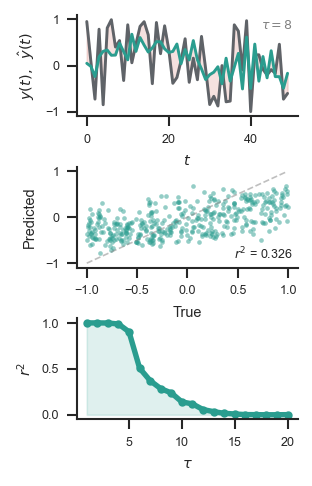

In [16]:
rd = trace["readout"]

ytrue = rd["y_tauB"].to_numpy()
yhat  = rd["yhat_tauB"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(1.9, 3.5), gridspec_kw={"hspace":0.5})

ax = axes[0]
nn = min(50, len(ytrue))
ax.plot(ytrue[:nn], color="#5f6368", lw=1.4, label="True")
ax.plot(yhat[:nn],  color=COL["mc"],  lw=1.4, label="Predicted")
ax.fill_between(range(nn), ytrue[:nn], yhat[:nn], color=COL["disp"], alpha=0.15)
ax.set_xlabel("$t$"); ax.set_ylabel("$y(t), \;\; \hat{y}(t)$")
ax.text(0.98, 0.96, "$\\tau = 8$", transform=ax.transAxes,
        ha="right", va="top", fontsize=6, color="gray" )
#ax.legend(loc="upper right", frameon=False, fontsize=6)
sns.despine(ax=ax)

ax = axes[1]
ax.scatter(ytrue, yhat, s=5, alpha=0.5, color=COL["mc"], linewidths=0)
lims = [min(ytrue.min(), yhat.min()), max(ytrue.max(), yhat.max())]
ax.plot(lims, lims, lw=0.8, ls="--", color="gray", alpha=0.5)
r2 = pearsonr(ytrue, yhat)[0]**2
ax.text(0.98, 0.06, f"$r^2$ = {r2:.3f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=6)
ax.set_xlabel("True"); ax.set_ylabel("Predicted")
sns.despine(ax=ax)

ax = axes[2]
mc = trace["mccurve"]
ax.plot(mc["tau"], mc["r2"], "-o", color=COL["mc"], lw=2.6, ms=3, solid_capstyle="round")
ax.fill_between(mc["tau"], 0, mc["r2"], color=COL["mc"], alpha=0.15)
sns.despine(ax=ax); ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$r^2$"); ax.tick_params(labelsize=6)


plt.savefig(FIG_PARTS/"trace_fit.pdf", dpi=600, bbox_inches="tight", transparent=True)
plt.tight_layout()

plt.show()

In [17]:
try:
    from nilearn import plotting
    from nilearn.plotting import find_parcellation_cut_coords
    if AAL_NII.exists():
        coords = find_parcellation_cut_coords(labels_img=str(AAL_NII))[:N_NODES]
        
        node_val = np.ones(len(coords))
        disp = plotting.plot_markers(node_values=node_val, node_coords=coords,
                                     display_mode="x", node_size=28,node_cmap="Purples", 
                                     colorbar=False, alpha=0.9)
        for ext in ("pdf","png"): disp.savefig(FIG_PARTS/f"brain_nodes.{ext}", dpi=600)
        disp.close(); print("  part: brain_nodes (nilearn,", len(coords), "nodes)")
    else:
        print("AAL.nii not found at", AAL_NII)
except Exception as e:
    print("nilearn brain glyph skipped:", str(e)[:130])

  part: brain_nodes (nilearn, 90 nodes)


saved figures\figure1_mc_predictors.[pdf|png]


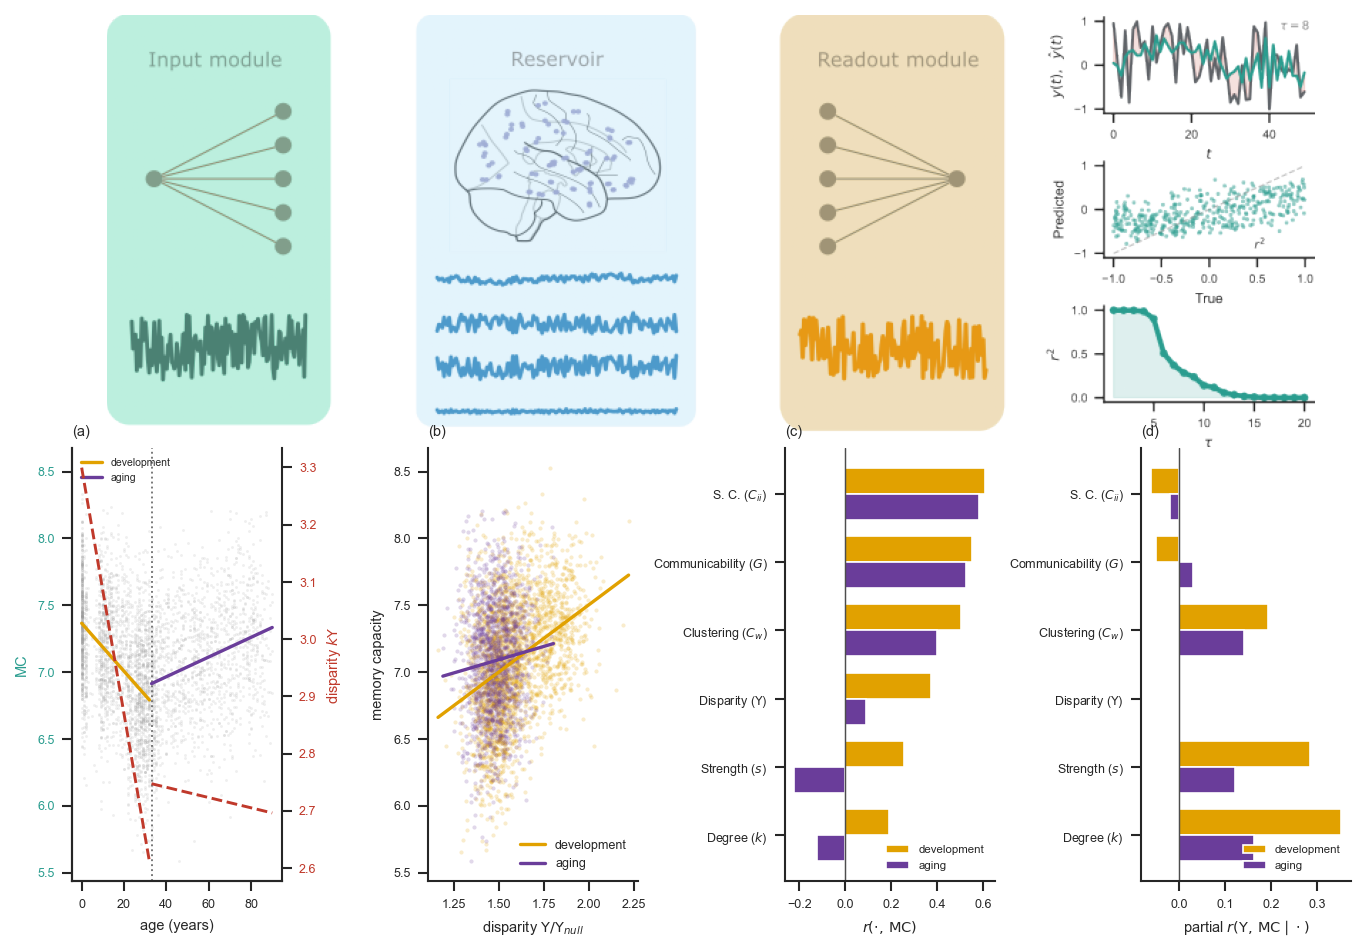

In [33]:
fig = plt.figure(figsize=FIGSIZE)
outer = fig.add_gridspec(2, 1, height_ratios=[0.8, 0.8], hspace=0.0)


# paradigm placeholder (assembled in Inkscape from figures/fig1_parts/)
axp = fig.add_subplot(outer[0]); axp.axis("off")

from matplotlib.image import imread
img = imread(str(FIG_PARTS / "testfig.png"))
axp.imshow(img)  # equal, NO auto
axp.set_xlim(0, img.shape[1]); axp.set_ylim(img.shape[0], 0); axp.axis("off")


g = outer[1].subgridspec(1, 4, wspace=0.7)
dev_df = df[df["cohort"]=="development"]; age_df = df[df["cohort"]=="aging"]

# (a) MC and disparity across the lifespan -- exact-age means, no binning, no CI bands
axU = fig.add_subplot(g[0,0])

df_mc = df.dropna(subset=["MC", "age"])
df_kY = df.dropna(subset=["kY_obs", "age"])

# --- scatter MC (gris neutro, sin color por dataset) ---
axU.scatter(df_mc["age"], df_mc["MC"], s=2, alpha=0.15,
            color="0.6", linewidths=0, zorder=1)

# --- linear fit MC por cohort ---
for coh, col in COHORT_COL.items():
    sub = df_mc[df_mc["cohort"] == coh]
    b = np.polyfit(sub["age"], sub["MC"], 1)
    xs = np.linspace(sub["age"].min(), sub["age"].max(), 100)
    axU.plot(xs, np.polyval(b, xs), color=col, lw=1.6, zorder=5,
             label=coh)

axU.set_ylabel("MC", color=COL["mc"])
axU.tick_params(axis="y", labelcolor=COL["mc"])
axU.set_xlabel("age (years)")
axU.axvline(AGE_SPLIT, color="0.45", ls=":", lw=0.9, zorder=2)
axU.legend(fontsize=5, frameon=False, loc="upper left")

# --- doble eje: solo fits lineales de kY ---
ax2 = axU.twinx()
for coh in ("development", "aging"):
    sub = df_kY[df_kY["cohort"] == coh]
    b = np.polyfit(sub["age"], sub["kY_obs"], 1)
    xs = np.linspace(sub["age"].min(), sub["age"].max(), 100)
    ax2.plot(xs, np.polyval(b, xs),
             color=COL["disp"], lw=1.4, ls="--", zorder=4)

ax2.set_ylabel(r"disparity $k\Upsilon$", color=COL["disp"])
ax2.tick_params(axis="y", labelcolor=COL["disp"])
ax2.spines["right"].set_visible(True)

axU.set_title("(a)", fontsize=7, loc="left")

# (b) MC vs disparity by regime -- light scatter + linear trend, no binning
axB = fig.add_subplot(g[0,1])
for coh in ("development","aging"):
    d = df[df["cohort"]==coh].dropna(subset=["Ratio","MC"]); c = COHORT_COL[coh]
    axB.scatter(d["Ratio"], d["MC"], s=4, alpha=0.20, color=c, lw=0)
    if len(d) > 10:
        b = np.polyfit(d["Ratio"], d["MC"], 1)
        xs = np.linspace(d["Ratio"].min(), d["Ratio"].max(), 50)
        axB.plot(xs, np.polyval(b, xs), color=c, lw=1.6, label=coh)
axB.set_xlabel(r"disparity $\Upsilon/\Upsilon_{null}$"); axB.set_ylabel("memory capacity")
axB.legend(frameon=False, fontsize=6, loc="best")
axB.set_title("(b)", fontsize=7, loc="left")

# métricas y orden compartidos por (c) y (d)
preds = [("Ratio", r"Disparity ($\Upsilon$)"), ("comm_mean", r"Communicability ($G$)"),
         ("C_w", r"Clustering ($C_w$)"), ("self_comm_mean", r"S. C. ($C_{ii}$)"),
         ("strength", r"Strength ($s$)"), ("degree", r"Degree ($k$)")]
preds = [(c, l) for c, l in preds if c in df.columns]

# (c) r(metric, MC) by regime -- no stars, full-word labels
rc = []
for c, l in preds:
    rd_, _ = pearson_p(dev_df[c], dev_df["MC"]); ra_, _ = pearson_p(age_df[c], age_df["MC"])
    rc.append([c, l, rd_, ra_])
rc.sort(key=lambda t: abs(t[2]) if np.isfinite(t[2]) else 0)   # orden por |r dev|
order = [t[0] for t in rc]; lab = {c: l for c, l in preds}

axH = fig.add_subplot(g[0,2])
y = np.arange(len(rc)); h = 0.38
axH.barh(y + h/2, [t[2] for t in rc], h, color=COL["dev"], label="development")
axH.barh(y - h/2, [t[3] for t in rc], h, color=COL["aging"], label="aging")
axH.axvline(0, color="0.3", lw=0.7); axH.set_yticks(y); axH.set_yticklabels([t[1] for t in rc])
axH.set_xlabel(r"$r(\cdot,\,\mathrm{MC})$")
axH.legend(loc="lower right", frameon=False, fontsize=5.5)
axH.set_title("(c)", fontsize=7, loc="left")

# (d) partial r(Y, MC | metric) by regime -- mismas métricas y orden que (c), no stars
axE = fig.add_subplot(g[0,3])
def _pr(frame, cov):
    if cov == "Ratio":                       # condicionar Y sobre sí misma es degenerado
        return np.nan
    return partial_r(frame["Ratio"], frame["MC"], frame[cov])[0]
dv = [_pr(dev_df, c) for c in order]; av = [_pr(age_df, c) for c in order]
axE.barh(y + h/2, dv, h, color=COL["dev"], label="development")
axE.barh(y - h/2, av, h, color=COL["aging"], label="aging")
axE.axvline(0, color="0.3", lw=0.7); axE.set_yticks(y); axE.set_yticklabels([lab[c] for c in order])
axE.set_xlabel(r"partial $r(\Upsilon,\,\mathrm{MC}\mid\cdot)$")
axE.legend(loc="lower right", frameon=False, fontsize=5.5)
axE.set_title("(d)", fontsize=7, loc="left")


save_fig(fig, "figure1_mc_predictors"); plt.show()


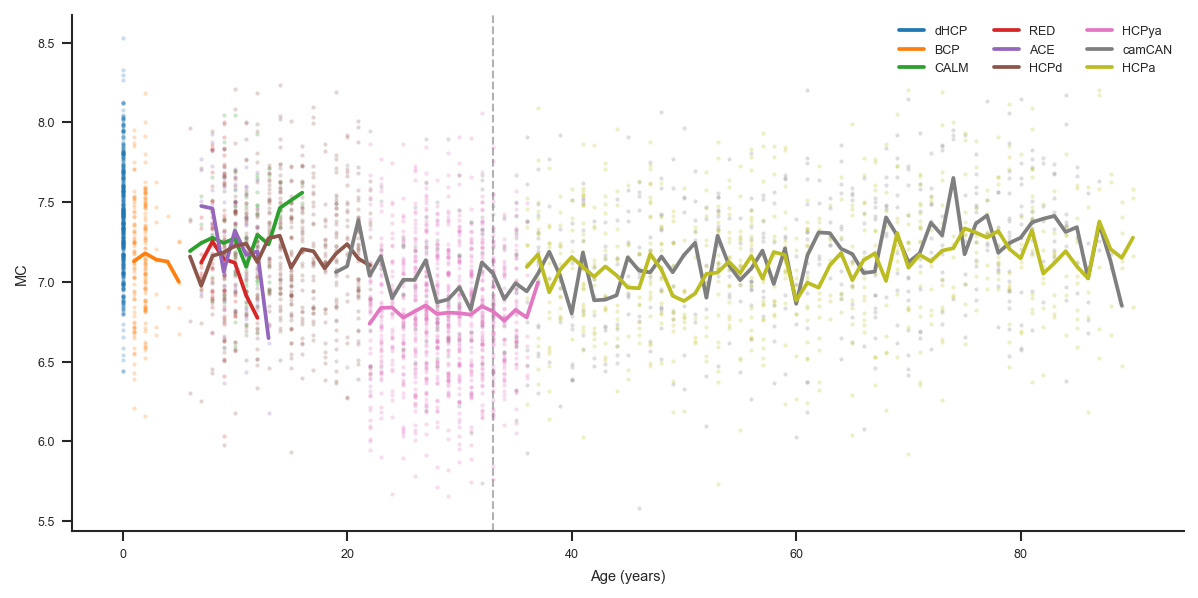

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for ds_id, ds_name in DS_NAMES.items():
    sub = df[df["dataset"] == ds_id].dropna(subset=["MC", "age"])
    if len(sub) < 5:
        continue
    col = DS_PALETTE[ds_id]

    # scatter
    ax.scatter(sub["age"], sub["MC"], s=4, alpha=0.25, color=col, linewidths=0)

    # media por edad exacta
    mean_by_age = sub.groupby("age")["MC"].mean().reset_index().sort_values("age")
    ax.plot(mean_by_age["age"], mean_by_age["MC"], color=col, lw=1.8, label=ds_name)

ax.axvline(AGE_SPLIT, color="gray", lw=1, ls="--", alpha=0.6)
ax.set_xlabel("Age (years)")
ax.set_ylabel("MC")
ax.legend(fontsize=6, ncol=3, frameon=False)
sns.despine()
plt.tight_layout()

## 6 · Figure 2 — communicability decomposition, regime change, multivariate picture

(a) The Taylor validation: pooled over nodes and subjects, the exact self-communicability
$C_{ii}=(e^{W})_{ii}$ against its order-2 approximation $1+\tfrac12(W^2)_{ii}=1+\tfrac12 s_i^2 Y_i$
(disparity); the inset shows the order-3 term tracking weighted clustering. (b) The R²
decomposition of MC (Table III) for development vs aging — Υ alone collapses in aging
while Υ+$C_w$ and Υ+$T_3$ stay near 0.45: the heterogeneity→triangle regime change.
(c) A PCA of the coupled family (Υ, $C_w$, $G$, MC, age). (d) Their correlation matrix.

saved figures\figure2_decomposition_regime.[pdf|png]


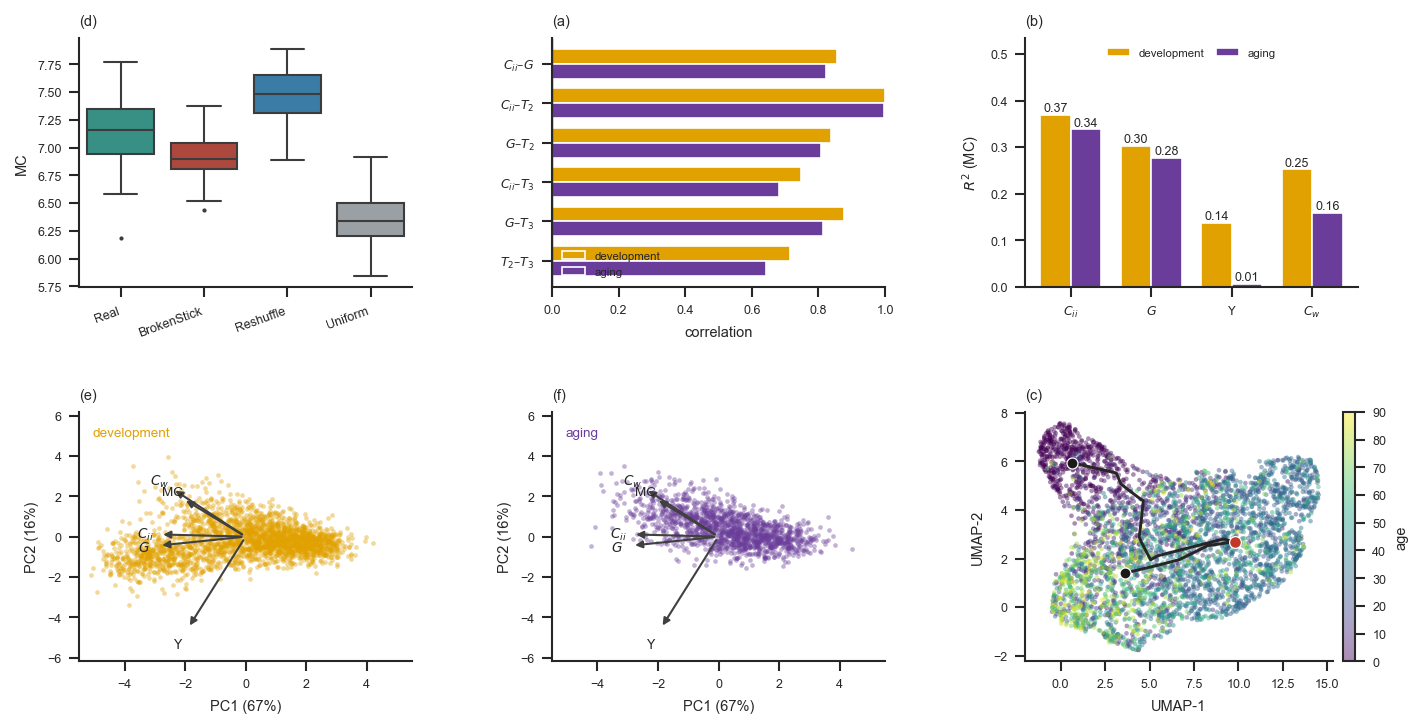

In [39]:
fig = plt.figure(figsize=(11, 5.4))
g = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.42)
cohorts = [("development", COL["dev"]), ("aging", COL["aging"])]
dev_df = df[df["cohort"]=="development"]; age_df = df[df["cohort"]=="aging"]

# ---- shared structure-function family: PCA (for e,f) + manifold embedding (for c), computed once ----
_fcols = [c for c in ["Ratio","C_w","comm_mean","self_comm_mean","MC"] if c in df.columns]
flabs  = {"Ratio": r"$\Upsilon$", "C_w": r"$C_w$", "comm_mean": r"$G$",
          "self_comm_mean": r"$C_{ii}$", "MC": "MC"}
Pf  = df.dropna(subset=_fcols+["age"]).copy()
_Xv = Pf[_fcols].values
Xf  = (_Xv - _Xv.mean(0)) / _Xv.std(0)
_Up, Sp, Vtp = np.linalg.svd(Xf - Xf.mean(0), full_matrices=False)
ev = (Sp**2)/(Sp**2).sum(); scores = _Up[:, :2]*Sp[:2]; load = Vtp[:2].T
if HAS_UMAP:
    emb = umap.UMAP(n_neighbors=25, min_dist=0.3, random_state=SEED).fit_transform(Xf)
    xlab, ylab = "UMAP-1", "UMAP-2"
else:
    emb = scores; xlab, ylab = "PC1", "PC2"

# (d) weight surrogates -- MC of the real network vs three nulls
axd = fig.add_subplot(g[0,0])
order = ["Real","BrokenStick","Reshuffle","Uniform"]
pal = {"Real":COL["mc"], "BrokenStick":COL["disp"], "Reshuffle":COL["comm"], "Uniform":COL["null"]}
sm = surr.groupby(["subject_id","model"])["MC"].mean().reset_index()
sns.boxplot(data=sm, x="model", y="MC", order=order, palette=pal, ax=axd, fliersize=1)
axd.set_xlabel(""); axd.set_ylabel("MC")
axd.set_xticklabels(axd.get_xticklabels(), rotation=20, ha="right")
axd.set_title("(d)", fontsize=7, loc="left")

# (a) pairwise correlations among C_ii, G and the Taylor terms T2 (order-2) and T3 (order-3), by cohort
axa = fig.add_subplot(g[0,1])
qmap = {"C":"self_comm_mean", "G":"comm_mean", "T2":"T2_mean", "T3":"T3_mean"}
pairs = [("C","G",   r"$C_{ii}$–$G$"),
         ("C","T2",  r"$C_{ii}$–$T_2$"),
         ("G","T2",  r"$G$–$T_2$"),
         ("C","T3",  r"$C_{ii}$–$T_3$"),
         ("G","T3",  r"$G$–$T_3$"),
         ("T2","T3", r"$T_2$–$T_3$")]
def _rc(frame, a, b): return (pearson_p(frame[qmap[a]], frame[qmap[b]])[0])**2
yb = np.arange(len(pairs))[::-1]; h = 0.38
dv = [_rc(dev_df, a, b) for a,b,_ in pairs]; av = [_rc(age_df, a, b) for a,b,_ in pairs]
axa.barh(yb + h/2, dv, h, color=COL["dev"], label="development")
axa.barh(yb - h/2, av, h, color=COL["aging"], label="aging")
axa.axvline(0, color="0.3", lw=0.7); axa.set_xlim(-1, 1)
axa.set_yticks(yb); axa.set_yticklabels([l for _,_,l in pairs])
axa.set_xlim(0,1);
axa.set_xlabel("correlation"); axa.legend(frameon=False, fontsize=5.5, loc="lower left")
axa.set_title("(a)", fontsize=7, loc="left")

# (b) variance in MC explained by C_ii, G, disparity Y, clustering C_w -- by cohort
axb = fig.add_subplot(g[0,2])
def _r2(frame, col):
    sub = frame.dropna(subset=[col, "MC"])
    return fit_linear(sub[col].values, sub["MC"].values)[0] if len(sub) > 10 else np.nan
predsB = [("self_comm_mean", r"$C_{ii}$"), ("comm_mean", r"$G$"),
          ("Ratio", r"$\Upsilon$"), ("C_w", r"$C_w$")]
predsB = [(c,l) for c,l in predsB if c in df.columns]
xb = np.arange(len(predsB)); w = 0.38
dr = [_r2(dev_df, c) for c,_ in predsB]; ar = [_r2(age_df, c) for c,_ in predsB]
axb.bar(xb-w/2, dr, w, color=COL["dev"], label="development")
axb.bar(xb+w/2, ar, w, color=COL["aging"], label="aging")
_ym = max([v for v in dr+ar if np.isfinite(v)] + [1e-6]); off = 0.02*_ym
for xi,v in zip(xb-w/2, dr):
    if np.isfinite(v): axb.text(xi, v+off, f"{v:.2f}", ha="center", fontsize=6)
for xi,v in zip(xb+w/2, ar):
    if np.isfinite(v): axb.text(xi, v+off, f"{v:.2f}", ha="center", fontsize=6)
axb.set_ylim(0, _ym*1.45); axb.set_xticks(xb); axb.set_xticklabels([l for _,l in predsB])
axb.set_ylabel(r"$R^2$ (MC)")
axb.legend(frameon=False, fontsize=5.5, loc="upper center", ncol=2, columnspacing=1.0)
axb.set_title("(b)", fontsize=7, loc="left")


# ---- (e),(f): two biplots in the SAME shared PCA space (one PCA fit on all subjects) ----
scale = 0.9*np.abs(scores).max() / max(np.abs(load).max(), 1e-9)
_pts = np.vstack([scores, load*scale*1.25])
_xm = np.abs(_pts[:,0]).max()*1.08; _ymx = np.abs(_pts[:,1]).max()*1.08
def _biplot(ax, coh, color, tag):
    msk = (Pf["cohort"] == coh).values
    ax.scatter(scores[msk,0], scores[msk,1], s=5, color=color, alpha=0.4, lw=0, rasterized=True)
    for col, v in zip(_fcols, load):
        ax.annotate("", xy=(v[0]*scale, v[1]*scale), xytext=(0,0),
                    arrowprops=dict(arrowstyle="-|>", color="0.25", lw=1.0))
        ax.text(v[0]*scale*1.16, v[1]*scale*1.16, flabs.get(col, col),
                fontsize=6.5, ha="center", va="center")
    ax.set_xlim(-_xm, _xm); ax.set_ylim(-_ymx, _ymx)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.0f}%)"); ax.set_ylabel(f"PC2 ({ev[1]*100:.0f}%)")
    ax.text(0.04, 0.94, tag, transform=ax.transAxes, fontsize=6.5, color=color, va="top")

# (e) PCA biplot -- development
axe = fig.add_subplot(g[1,0]); _biplot(axe, "development", COL["dev"], "development")
axe.set_title("(e)", fontsize=7, loc="left")

# (f) PCA biplot -- aging
axf = fig.add_subplot(g[1,1]); _biplot(axf, "aging", COL["aging"], "aging")
axf.set_title("(f)", fontsize=7, loc="left")


# (c) manifold painted by age + lifespan trajectory (start, ~AGE_SPLIT, end marked)
axc = fig.add_subplot(g[1,2])
sc = axc.scatter(emb[:,0], emb[:,1], c=Pf["age"], cmap="viridis", s=5, alpha=0.45, lw=0, rasterized=True)
_e, _idx = geom_age_bins(Pf["age"].values, n_bins=24)
cx, cy, ca = [], [], []
for b in range(24):
    m = _idx == b
    if m.sum() >= 5:
        cx.append(emb[m,0].mean()); cy.append(emb[m,1].mean()); ca.append(Pf["age"].values[m].mean())
axc.plot(cx, cy, "-", color="0.15", lw=1.4, zorder=5)
if cx:
    axc.scatter([cx[0]],  [cy[0]],  s=28, color="0.1", zorder=6, edgecolor="white", lw=0.6)   # start (youngest)
    axc.scatter([cx[-1]], [cy[-1]], s=28, color="0.1", zorder=6, edgecolor="white", lw=0.6)   # end (oldest)
    j = int(np.argmin(np.abs(np.array(ca) - AGE_SPLIT)))
    axc.scatter([cx[j]], [cy[j]], s=32, color=COL["accent"], zorder=7, edgecolor="white", lw=0.6)  # turning point
axc.set_xlabel(xlab); axc.set_ylabel(ylab)
fig.colorbar(sc, ax=axc, fraction=0.046, pad=0.03, label="age")
axc.set_title("(c)", fontsize=7, loc="left")

save_fig(fig, "figure2_decomposition_regime"); plt.show()

## 7 · Secondary and supplementary panels

The surrogate, biological-input and IPC controls, the Mijalkov thresholding contrast, and
the extended PCA/UMAP multivariate analysis. These support the main text and live in the
supplement.

### 7a · Surrogate and biological-input controls, IPC orders

saved figures\supp_controls.[pdf|png]


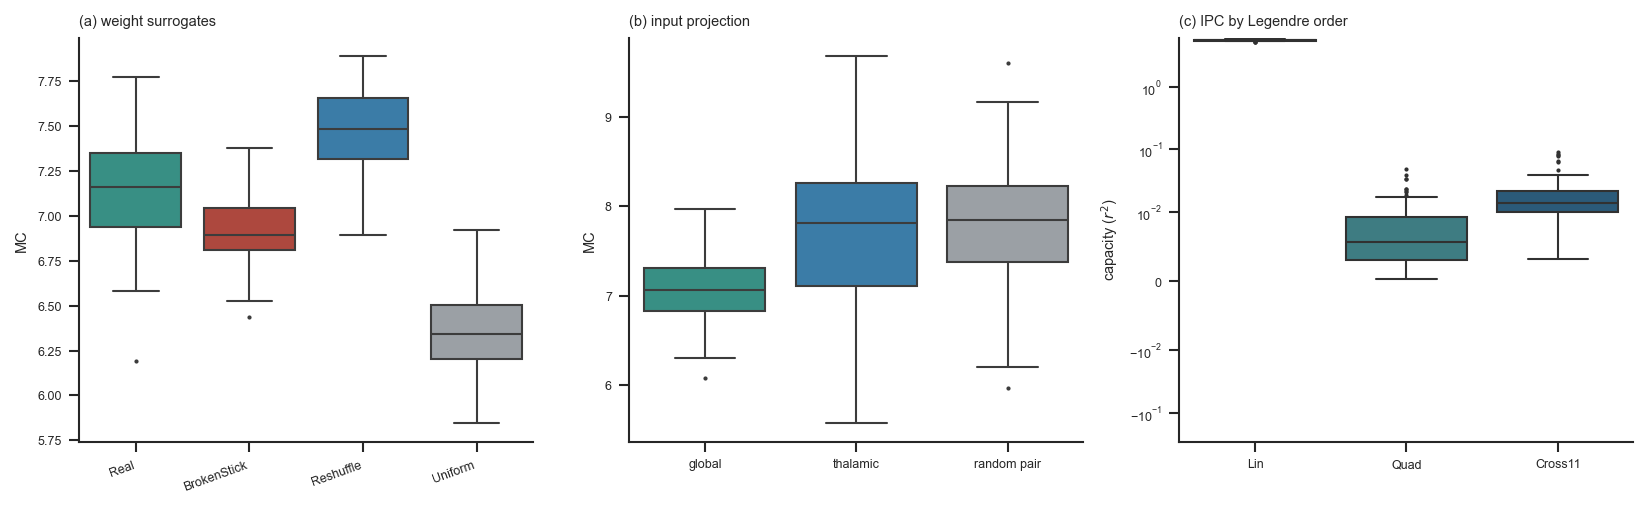

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

# surrogate boxplots
order = ["Real","BrokenStick","Reshuffle","Uniform"]
pal = {"Real":COL["mc"], "BrokenStick":COL["disp"], "Reshuffle":COL["comm"], "Uniform":COL["null"]}
sm = surr.groupby(["subject_id","model"])["MC"].mean().reset_index()
sns.boxplot(data=sm, x="model", y="MC", order=order, palette=pal, ax=axes[0], fliersize=1)
axes[0].set_title("(a) weight surrogates", fontsize=7, loc="left")
axes[0].set_xlabel(""); axes[0].set_ylabel("MC")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")

# bio boxplots
bm = bio.melt(id_vars="subject_id", value_vars=["MC","MC_Bio","MC_BioNull"],
              var_name="input", value_name="mc")
lbl = {"MC":"global","MC_Bio":"thalamic","MC_BioNull":"random pair"}
bm["input"] = bm["input"].map(lbl)
sns.boxplot(data=bm, x="input", y="mc", ax=axes[1], fliersize=1,
            palette=[COL["mc"], COL["comm"], COL["null"]])
axes[1].set_title("(b) input projection", fontsize=7, loc="left")
axes[1].set_xlabel(""); axes[1].set_ylabel("MC")

# IPC orders
ipc_cols = [c for c in ipc.columns if c != "subject_id"]
im = ipc.melt(id_vars="subject_id", value_vars=ipc_cols, var_name="order", value_name="cap")
sns.boxplot(data=im, x="order", y="cap", ax=axes[2], fliersize=1,
            palette=sns.color_palette("crest", len(ipc_cols)))
axes[2].set_yscale("symlog", linthresh=1e-2)
axes[2].set_title("(c) IPC by Legendre order", fontsize=7, loc="left")
axes[2].set_xlabel(""); axes[2].set_ylabel("capacity ($r^2$)")

fig.tight_layout(); save_fig(fig, "supp_controls"); plt.show()


### 7b · Mijalkov contrast — thresholded camCAN

Mijalkov et al. (2025) report MC *decreasing* with age using FA-weighted, thresholded
networks on camCAN. We cannot reproduce FA, but we can test whether **proportional
thresholding** of the camCAN streamline-count connectomes flips our macroscopic result.
We threshold camCAN to density 0.15, recompute MC, and correlate with age.

LinAlgError: SVD did not converge in Linear Least Squares

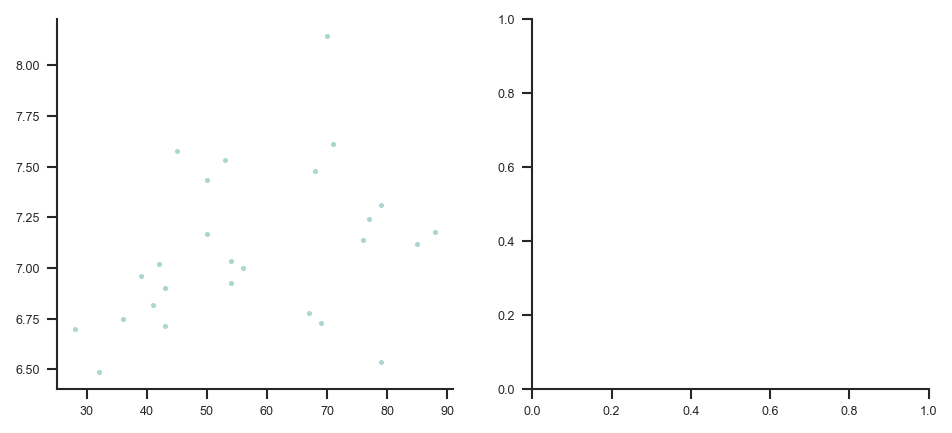

In [18]:
camcan = df[df["dataset"] == CAMCAN_DS].copy()
if len(camcan) >= 10:
    thr_cache = WORK_DIR / "mc_camcan_thr.pkl"
    if thr_cache.exists() and not FORCE_RECOMPUTE:
        mc_thr = pd.read_pickle(thr_cache)
    else:
        # export thresholded camCAN connectomes, run the workhorse on them
        path = CPP_DATA / "connectomes_camcan_thr.csv"
        with open(path, "w") as f:
            f.write("subject_id," + ",".join(f"w{k}" for k in range(N_NODES*N_NODES)) + "\n")
            for sid, A in zip(camcan["sid"], camcan["connectome"]):
                M = proportional_threshold(_mat(A), 0.15).flatten()
                f.write(f"{int(sid)}," + ",".join(f"{v:.6g}" for v in M) + "\n")
        write_config("cfg_mc_thr.txt", **RES, **MAIN, seed=SEED, threads=N_THREADS,
                     in_csv="data/connectomes_camcan_thr.csv", out_csv="mc_camcan_thr.csv")
        run_program("esn_mc", "cfg_mc_thr.txt", EXE)
        mc_thr = pd.read_csv("mc_camcan_thr.csv").rename(columns={"MC_Glob":"MC_thr"})
        mc_thr.to_pickle(thr_cache)
    camcan = camcan.merge(mc_thr.rename(columns={"subject_id":"sid"}), on="sid", how="left")

    fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.2))
    for a,(col,lab) in zip(ax, [("MC","streamline-count (raw)"), ("MC_thr","thresholded ρ=0.15")]):
        if col not in camcan: continue
        a.scatter(camcan["age"], camcan[col], s=6, color=COL["mc"], alpha=0.4, lw=0)
        b = np.polyfit(camcan["age"], camcan[col], 1); xs = np.linspace(camcan["age"].min(), camcan["age"].max(), 30)
        a.plot(xs, np.polyval(b, xs), color="0.2", lw=1.1)
        r,p = pearson_p(camcan["age"], camcan[col])
        a.text(0.05, 0.95, f"$r={r:+.2f}${sig_stars(p)}", transform=a.transAxes, va="top", fontsize=7)
        a.set_xlabel("age"); a.set_ylabel("MC"); a.set_title(lab, fontsize=7)
    fig.suptitle("camCAN: MC vs age — robustness to thresholding", fontsize=8)
    fig.tight_layout(); save_fig(fig, "supp_mijalkov_camcan"); plt.show()
else:
    print("camCAN subset too small for the thresholding contrast.")


### 7c · Extended PCA and UMAP (supplementary multivariate analysis)

In [18]:
# PCA global propio (la celda ya no depende de la antigua Figura 2)
_pcols = [("Ratio",r"$\Upsilon$"), ("C_w","$C_w$"), ("comm_mean","$G$"),
          ("self_comm_mean","$C_{ii}$"), ("MC","MC")]
pca_cols = [(c,l) for c,l in _pcols if c in df.columns]
P = df.dropna(subset=[c for c,_ in pca_cols]+["age"]).copy()
_X = P[[c for c,_ in pca_cols]].values
Xs = (_X - _X.mean(0)) / _X.std(0)
_U, S, Vt = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False)
scores = _U[:, :2] * S[:2]; ev = (S**2)/(S**2).sum()

saved figures\supp_pca_umap.[pdf|png]


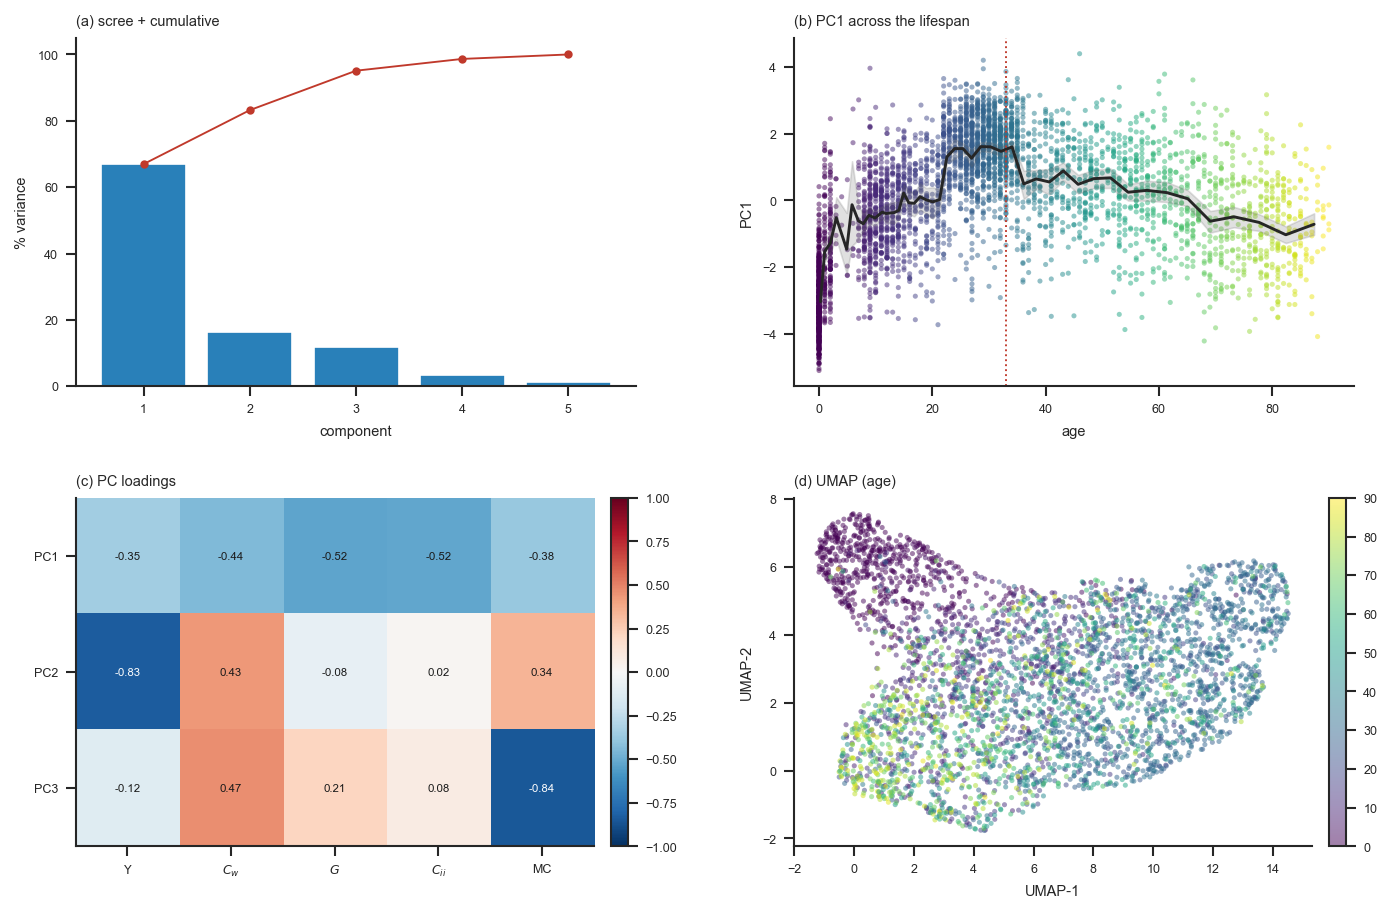

In [19]:
fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.28)

# scree
axs = fig.add_subplot(gs[0,0])
axs.bar(np.arange(1, len(ev)+1), ev*100, color=COL["comm"])
axs.plot(np.arange(1, len(ev)+1), np.cumsum(ev)*100, "o-", color=COL["accent"], ms=3)
axs.set_xlabel("component"); axs.set_ylabel("% variance"); axs.set_xticks(range(1,len(ev)+1))
axs.set_title("(a) scree + cumulative", fontsize=7, loc="left")

# PC1 vs age (the fold / turning point)
axf = fig.add_subplot(gs[0,1])
axf.scatter(P["age"], scores[:,0], c=P["age"], cmap="viridis", s=6, alpha=0.5, lw=0, rasterized=True)
cen, mean, lo, hi = binned_trajectory(P["age"].values, scores[:,0])
axf.plot(cen, mean, color="0.15", lw=1.4); axf.fill_between(cen, lo, hi, color="0.4", alpha=0.2)
axf.axvline(AGE_SPLIT, color=COL["accent"], ls=":", lw=0.9)
axf.set_xlabel("age"); axf.set_ylabel("PC1"); axf.set_title("(b) PC1 across the lifespan", fontsize=7, loc="left")

# loadings heatmap PC1-3
axl = fig.add_subplot(gs[1,0])
nL = min(3, Vt.shape[0]); L = Vt[:nL]
im = axl.imshow(L, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axl.set_xticks(range(len(pca_cols))); axl.set_xticklabels([l for _,l in pca_cols], fontsize=6)
axl.set_yticks(range(nL)); axl.set_yticklabels([f"PC{i+1}" for i in range(nL)], fontsize=6)
for i in range(nL):
    for j in range(len(pca_cols)):
        axl.text(j, i, f"{L[i,j]:.2f}", ha="center", va="center", fontsize=5.5,
                 color="white" if abs(L[i,j])>0.55 else "0.1")
axl.set_title("(c) PC loadings", fontsize=7, loc="left")
fig.colorbar(im, ax=axl, fraction=0.046, pad=0.03)

# UMAP (or PC1-PC2 by dataset fallback)
axu = fig.add_subplot(gs[1,1])
if HAS_UMAP:
    emb = umap.UMAP(n_neighbors=25, min_dist=0.3, random_state=SEED).fit_transform(Xs)
    scu = axu.scatter(emb[:,0], emb[:,1], c=P["age"], cmap="viridis", s=6, alpha=0.5, lw=0, rasterized=True)
    axu.set_xlabel("UMAP-1"); axu.set_ylabel("UMAP-2"); axu.set_title("(d) UMAP (age)", fontsize=7, loc="left")
    fig.colorbar(scu, ax=axu, fraction=0.046, pad=0.03)
else:
    for d in sorted(P["dataset"].unique()):
        m = P["dataset"] == d
        axu.scatter(scores[m,0], scores[m,1], s=6, alpha=0.5, lw=0,
                    color=DS_PALETTE.get(int(d)), label=DS_NAMES.get(int(d), str(d)))
    axu.legend(frameon=False, fontsize=5, ncol=2, loc="best")
    axu.set_xlabel("PC1"); axu.set_ylabel("PC2")
    axu.set_title("(d) PC1–PC2 by dataset (install umap-learn for UMAP)", fontsize=6.5, loc="left")

save_fig(fig, "supp_pca_umap"); plt.show()


## 8 · Closing notes

In [ ]:
print("FIGURES written to", FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob("*.pdf")): print("  ", f.name)
print("\nOpen decisions to confirm with advisor / in the manuscript:")
print("  - per-ROI G_i: off-diagonal node communicability (used here); the DECOMPOSITION")
print("    uses the DIAGONAL self-communicability C_ii (exact order-2 = disparity).")
print("  - Sobel test dropped: mediation shown via partial correlation (Fig 1c) + the")
print("    R^2 decomposition (Fig 2b); idiomatic for complex networks.")
print("  - clustering: Zhang-Horvath used for the order-3-matching term; Onnela available")
print("    via clustering_onnela() for the text.")
print("  - PCA main result in Fig 2c; extended PCA/UMAP in the supplement.")
print("\nReproduce from scratch: set FORCE_RECOMPILE=True, FORCE_RECOMPUTE=True and re-run.")


FIGURES written to C:\Users\Ale\Desktop\UB\NetLearn\ESNcpp\figures
   figure1_mc_predictors.pdf
   figure2_decomposition_regime.pdf
   figure3_performance_disparity.pdf
   figure4_pca_umap.pdf
   figureS_ipc_orders.pdf
   figureS_mijalkov.pdf
   figureS_pca_detail.pdf
   supp_controls.pdf
   supp_mijalkov_camcan.pdf
   supp_pca_umap.pdf

Open decisions to confirm with advisor / in the manuscript:
  - per-ROI G_i: off-diagonal node communicability (used here); the DECOMPOSITION
    uses the DIAGONAL self-communicability C_ii (exact order-2 = disparity).
  - Sobel test dropped: mediation shown via partial correlation (Fig 1c) + the
    R^2 decomposition (Fig 2b); idiomatic for complex networks.
  - clustering: Zhang-Horvath used for the order-3-matching term; Onnela available
    via clustering_onnela() for the text.
  - PCA main result in Fig 2c; extended PCA/UMAP in the supplement.

Reproduce from scratch: set FORCE_RECOMPILE=True, FORCE_RECOMPUTE=True and re-run.
